# E-Commerce Data Storytelling: Từ tăng trưởng doanh thu đến rủi ro hoàn trả

---

Notebook này kể lại câu chuyện kinh doanh qua **4 chương phân tích**, mỗi chương trả lời một câu hỏi chiến lược:

| Chương | Câu hỏi chiến lược | Phương pháp chính |
|:------:|:------|:------|
| **0** | Ai đang mua, và ai là "Core Customer"? | RFM Segmentation, Demographic breakdown |
| **1** | Kênh nào giữ chân khách tốt nhất? | Recency-based Churn Risk, Confidence Intervals |
| **2** | Khuyến mãi có thực sự tạo thêm giá trị? | Matched-pair Analysis (loại Selection Bias) |
| **3** | Rủi ro chất lượng và Churn nằm ở đâu? | Return impact analysis, Category profiling |

> **Lưu ý về LTV (Life-Time Value):** Trong giới hạn của dữ liệu lịch sử, chưa có mô hình dự phóng (predictive model như BG/NBD hay Gamma-Gamma). Các chỉ số giá trị vòng đời ở đây được tính bằng **Historical ARPU (Average Revenue Per User)** — tức tổng doanh thu chia cho số khách hàng. Đây là proxy hợp lý nhưng không phải "true LTV".


In [34]:
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Suppress toan bo FutureWarning ve palette/hue cua seaborn 0.14
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

DATA_DIR = Path("../data/raw")

customers = pd.read_csv(DATA_DIR / "customers.csv", parse_dates=["signup_date"])
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
order_items = pd.read_csv(DATA_DIR / "order_items.csv", low_memory=False)
promotions = pd.read_csv(DATA_DIR / "promotions.csv", parse_dates=["start_date", "end_date"])
returns = pd.read_csv(DATA_DIR / "returns.csv", parse_dates=["return_date"])
products = pd.read_csv(DATA_DIR / "products.csv")
reviews = pd.read_csv(DATA_DIR / "reviews.csv", parse_dates=["review_date"])
web_traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])

order_items["gross_revenue"] = order_items["quantity"] * order_items["unit_price"]
order_items["net_revenue"] = order_items["gross_revenue"] - order_items["discount_amount"].fillna(0.0)
order_items["promo_used_line"] = order_items[["promo_id", "promo_id_2"]].notna().any(axis=1)

# Toi uu RAM: chi lay cac cot can thiet truoc khi merge
order_value = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        gross_revenue=("gross_revenue", "sum"),
        net_revenue=("net_revenue", "sum"),
        discount_amount=("discount_amount", "sum"),
        promo_used=("promo_used_line", "max"),
    )
)

orders_enriched = orders.merge(order_value, on="order_id", how="left")
cols_to_merge = ["customer_id", "acquisition_channel", "age_group", "city"]
orders_enriched = orders_enriched.merge(
    customers[cols_to_merge],
    on="customer_id",
    how="left"
)

# --- TINH TOAN RFM & RECENCY ---
max_date = orders["order_date"].max()

rfm = (
    orders_enriched.groupby("customer_id", as_index=False)
    .agg(
        last_order_date=("order_date", "max"),
        Frequency=("order_id", "nunique"),
        Historical_ARPU=("net_revenue", "sum")
    )
)
rfm["Recency"] = (max_date - rfm["last_order_date"]).dt.days
rfm["Historical_ARPU_per_order"] = rfm["Historical_ARPU"] / rfm["Frequency"]

# Dinh nghia Churn Risk: Recency > 90 days
rfm["Churn_Risk"] = rfm["Recency"] > 90

# RFM Scoring (1-4, 4 la tot nhat; Recency 4 = gan day nhat)
rfm["R_Score"] = pd.qcut(rfm["Recency"], q=4, labels=[4, 3, 2, 1], duplicates='drop')
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm["M_Score"] = pd.qcut(rfm["Historical_ARPU"], q=4, labels=[1, 2, 3, 4], duplicates='drop')

def assign_segment(row):
    if row["R_Score"] == 4 and row["F_Score"] >= 3 and row["M_Score"] >= 3:
        return "Champion"
    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal"
    elif row["Churn_Risk"]:
        return "At Risk / Churned"
    else:
        return "Standard"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)
customers_rfm = customers.merge(rfm, on="customer_id", how="left")


---
## Chuong 0. Demographic khach hang & Core Segments (RFM)

**Muc dich:** Truoc khi di vao cac cau hoi chien luoc, chung ta can hieu *ai dang mua* va *ai la "Core Customers"*.

- **RFM Segmentation** phan loai khach hang thanh 4 nhom: Champion, Loyal, Standard, At Risk/Churned.
- Bang duoi dung `style.format` ket hop `background_gradient` de lam noi bat cac chi so hieu suat thay vi dung `.round()` lam mat do chinh xac.


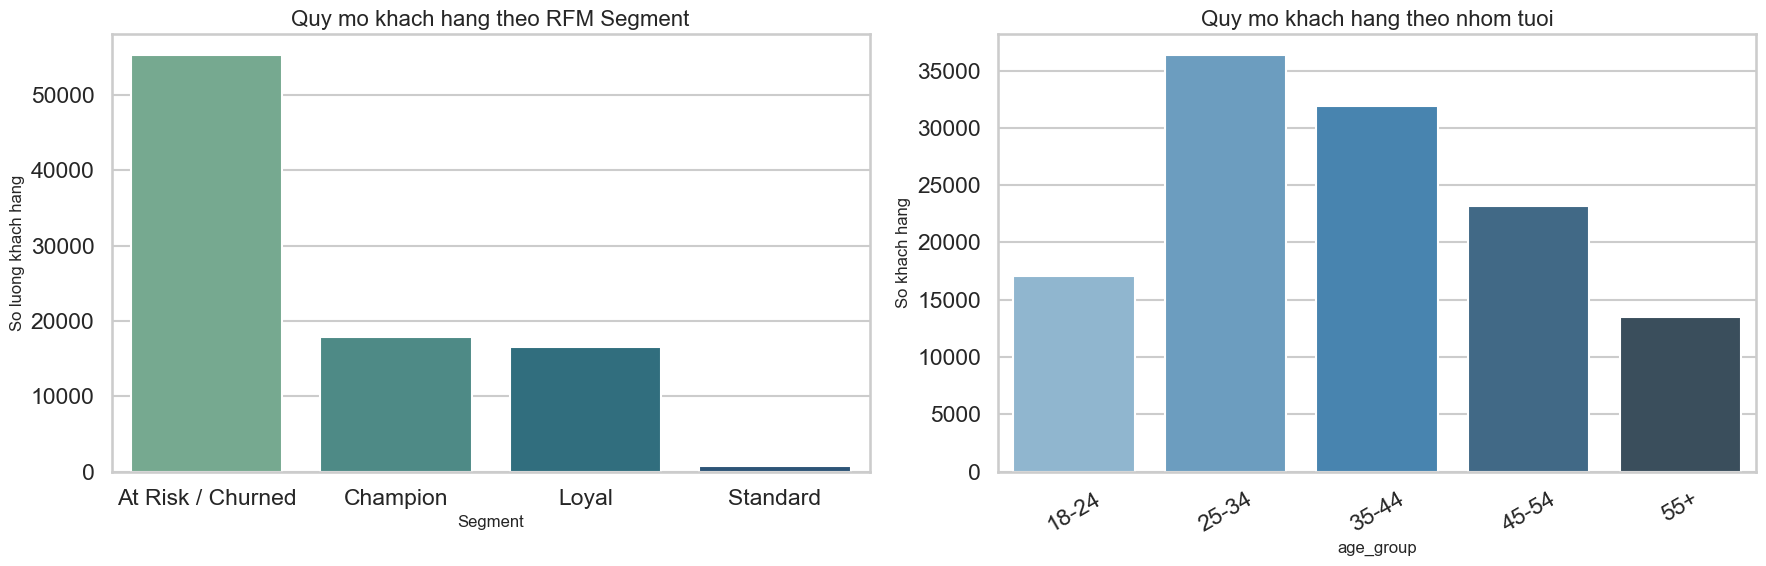

,Segment,Customers,Avg_Recency,Avg_Frequency,Total_Revenue,Avg_Historical_ARPU
1,Champion,"17,847",153.8 days,16.94 orders,"$7,528,720,649","$421,848"
2,Loyal,"16,465",586.9 days,11.25 orders,"$4,426,865,239","$268,865"
0,At Risk / Churned,"55,260","1,823.6 days",2.86 orders,"$3,687,443,472","$66,729"
3,Standard,674,38.8 days,2.24 orders,"$37,839,904","$56,142"


In [42]:
# Bieu do Segment & Age
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

segment_counts = customers_rfm["Segment"].value_counts()
sns.barplot(
    x=segment_counts.index, y=segment_counts.values,
    hue=segment_counts.index, palette="crest", legend=False, ax=axes[0]
)
axes[0].set_title("Quy mo khach hang theo RFM Segment", fontsize=16)
axes[0].set_ylabel("So luong khach hang")

age_counts = customers_rfm["age_group"].dropna().value_counts().sort_index()
sns.barplot(
    x=age_counts.index, y=age_counts.values,
    hue=age_counts.index, palette="Blues_d", legend=False, ax=axes[1]
)
axes[1].set_title("Quy mo khach hang theo nhom tuoi", fontsize=16)
axes[1].set_ylabel("So khach hang")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Bang Summary theo Segment (style.format thay vi round)
segment_summary = (
    customers_rfm.groupby("Segment", as_index=False)
    .agg(
        Customers=("customer_id", "nunique"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Total_Revenue=("Historical_ARPU", "sum"),
        Avg_Historical_ARPU=("Historical_ARPU", "mean")
    )
).sort_values("Total_Revenue", ascending=False)

display(segment_summary.style.format({
    "Customers": "{:,.0f}",
    "Avg_Recency": "{:,.1f} days",
    "Avg_Frequency": "{:,.2f} orders",
    "Total_Revenue": "${:,.0f}",
    "Avg_Historical_ARPU": "${:,.0f}"
}).background_gradient(cmap="YlGnBu", subset=["Total_Revenue", "Avg_Historical_ARPU"]))


### Bang tong hop theo nhom tuoi

So sanh AOV, tan suat mua, va Historical ARPU giua cac nhom tuoi de xac dinh nhom nao dang tao gia tri cao nhat.


In [43]:
age_value = (
    orders_enriched.dropna(subset=["age_group"])
    .groupby("age_group", as_index=False)
    .agg(
        Customers=("customer_id", "nunique"),
        Orders=("order_id", "nunique"),
        Total_Revenue=("net_revenue", "sum"),
        Avg_Order_Value=("net_revenue", "mean")
    )
)
age_value["Orders_per_Customer"] = age_value["Orders"] / age_value["Customers"]
age_value["Historical_ARPU"] = age_value["Total_Revenue"] / age_value["Customers"]

age_summary = age_value.sort_values("Total_Revenue", ascending=False)

display(age_summary.style.format({
    "Customers": "{:,.0f}",
    "Orders": "{:,.0f}",
    "Total_Revenue": "${:,.0f}",
    "Avg_Order_Value": "${:,.0f}",
    "Orders_per_Customer": "{:,.2f}",
    "Historical_ARPU": "${:,.0f}"
}).background_gradient(cmap="YlGnBu", subset=["Total_Revenue", "Historical_ARPU"]))


,age_group,Customers,Orders,Total_Revenue,Avg_Order_Value,Orders_per_Customer,Historical_ARPU
1,25-34,"26,802","190,622","$4,630,010,667","$24,289",7.11,"$172,749"
2,35-44,"23,642","170,368","$4,126,281,874","$24,220",7.21,"$174,532"
3,45-54,"17,193","124,138","$3,019,379,835","$24,323",7.22,"$175,617"
0,18-24,"12,599","89,057","$2,152,381,726","$24,169",7.07,"$170,838"
4,55+,"10,010","72,760","$1,752,815,164","$24,090",7.27,"$175,106"


### Thanh pho nao chiu chi hon?

Ghep so khach hang va doanh thu de nhin ro thanh pho co quy mo lon hay thuc su "chiu chi" (Historical ARPU/khach cao).


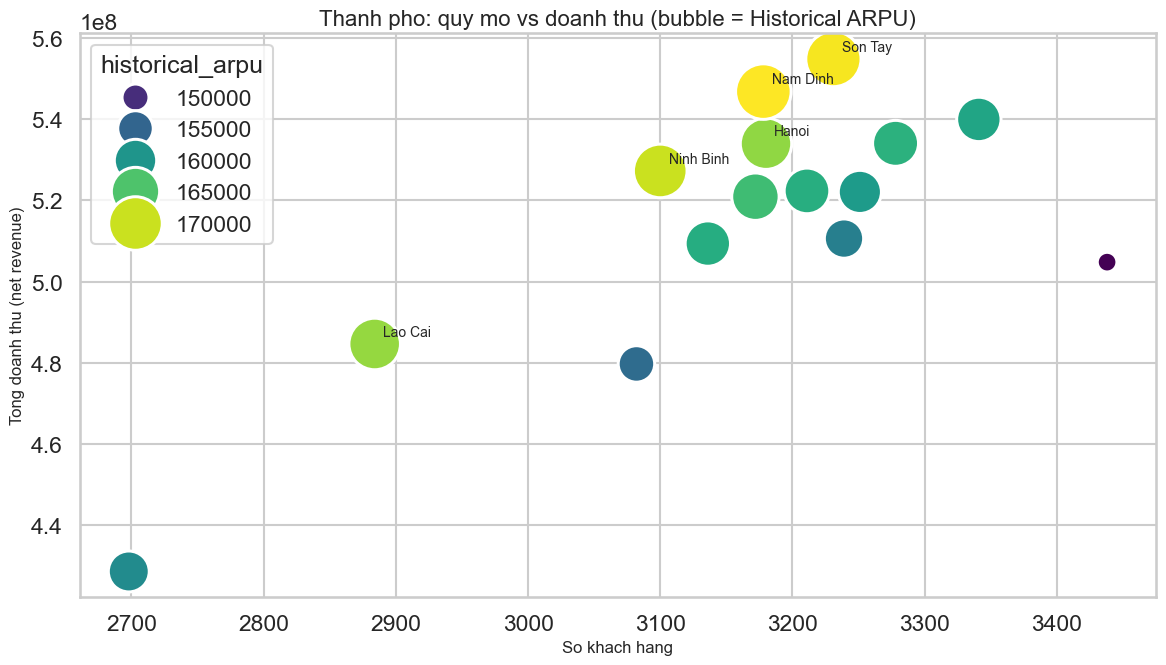

In [44]:
city_value = (
    orders_enriched.dropna(subset=["city"])
    .groupby("city", as_index=False)
    .agg(customers=("customer_id", "nunique"), total_revenue=("net_revenue", "sum"))
)
city_value["historical_arpu"] = city_value["total_revenue"] / city_value["customers"]

city_plot = city_value.sort_values("customers", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=city_plot,
    x="customers",
    y="total_revenue",
    size="historical_arpu",
    sizes=(200, 1600),
    hue="historical_arpu",
    palette="viridis",
    ax=ax,
    legend="brief",
)
ax.set_title("Thanh pho: quy mo vs doanh thu (bubble = Historical ARPU)", fontsize=16)
ax.set_xlabel("So khach hang")
ax.set_ylabel("Tong doanh thu (net revenue)")

for _, row in city_plot.sort_values("historical_arpu", ascending=False).head(5).iterrows():
    ax.annotate(
        row["city"],
        (row["customers"], row["total_revenue"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=10,
    )

plt.tight_layout()
plt.show()


---
**Nhan dinh tu Chuong 0:** Chung ta da biet *ai dang mua* va phan loai duoc nhom Core Customers bang RFM. Cau hoi tiep theo la: **kenh nao giu chan khach tot nhat, va kenh nao dang co nguy co mat khach?**


## Chuong 1. Phan bo rui ro Churn & Hieu suat Kenh thu hut (Acquisition)

**Muc dich:** Xem xet ty le khach hang co rui ro roi bo (Churn Risk = Recency > 90 days) o tung kenh Acquisition. Kenh nao mang lai ARPU tot *va* giu chan khach tot?

- Bieu do ARPU su dung **95% Confidence Interval** (`errorbar='ci'`) de loai tru nhieu du lieu khi so sanh gia tri giua cac kenh.
- Bieu do Churn Rate duoc tach rieng de tranh bi de label.


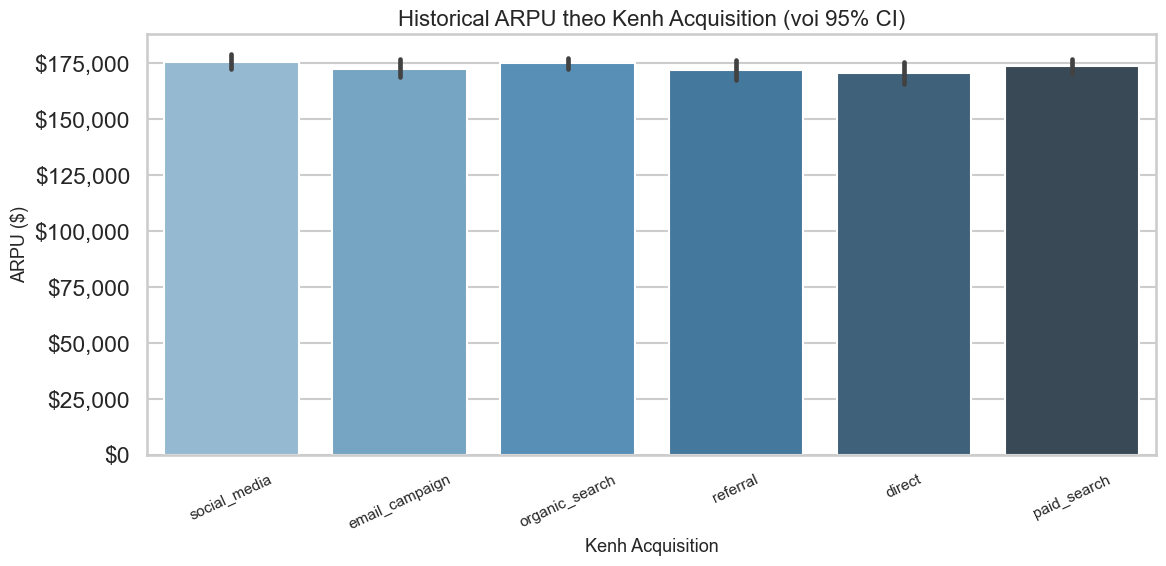

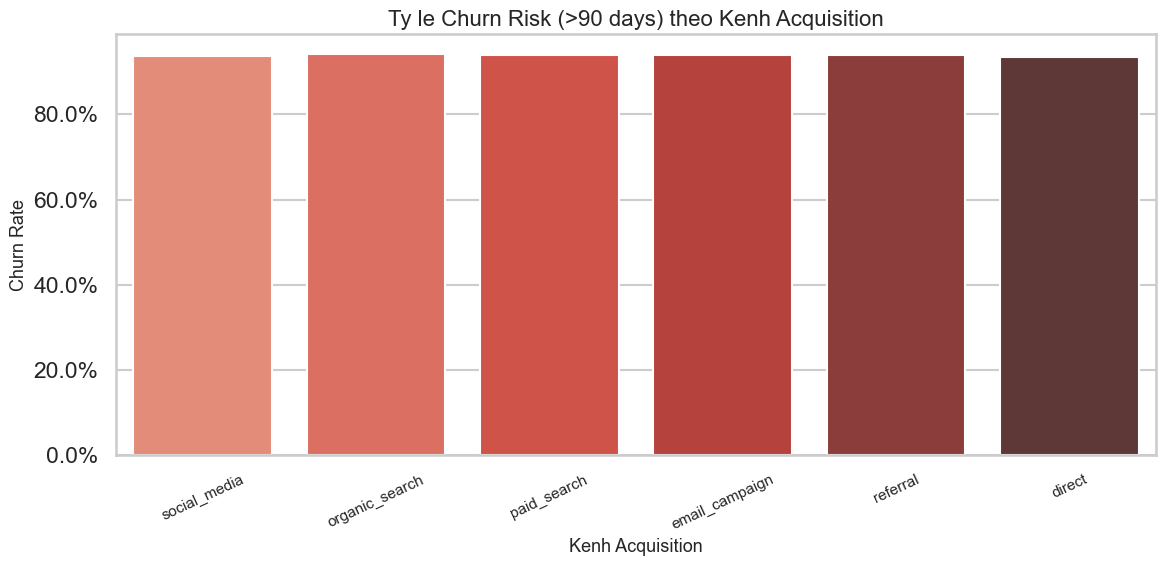

,acquisition_channel,Avg_ARPU,Churn_Rate
5,social_media,"$175,458.1",93.6%
2,organic_search,"$174,849.3",94.0%
3,paid_search,"$173,475.2",94.0%
1,email_campaign,"$172,414.7",93.8%
4,referral,"$171,955.6",93.9%
0,direct,"$170,480.6",93.4%


In [38]:
channel_metrics = (
    customers_rfm.groupby("acquisition_channel", as_index=False)
    .agg(
        Avg_ARPU=("Historical_ARPU", "mean"),
        Churn_Rate=("Churn_Risk", "mean")
    )
).sort_values("Avg_ARPU", ascending=False)

# --- BIEU DO 1: Historical ARPU theo Kenh (rieng biet, khong bi de label) ---
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=customers_rfm,
    x="acquisition_channel",
    y="Historical_ARPU",
    hue="acquisition_channel",
    palette="Blues_d",
    legend=False,
    ax=ax,
    errorbar=("ci", 95)
)
ax.set_title("Historical ARPU theo Kenh Acquisition (voi 95% CI)", fontsize=16)
ax.set_xlabel("Kenh Acquisition", fontsize=13)
ax.set_ylabel("ARPU ($)", fontsize=13)
ax.tick_params(axis="x", rotation=25, labelsize=11)
ax.yaxis.set_major_formatter(lambda x, pos: f"${x:,.0f}")
plt.tight_layout()
plt.show()

# --- BIEU DO 2: Churn Rate theo Kenh (rieng biet) ---
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=channel_metrics,
    x="acquisition_channel",
    y="Churn_Rate",
    hue="acquisition_channel",
    palette="Reds_d",
    legend=False,
    ax=ax,
)
ax.set_title("Ty le Churn Risk (>90 days) theo Kenh Acquisition", fontsize=16)
ax.set_xlabel("Kenh Acquisition", fontsize=13)
ax.set_ylabel("Churn Rate", fontsize=13)
ax.tick_params(axis="x", rotation=25, labelsize=11)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
plt.tight_layout()
plt.show()

# Bang so sanh
display(channel_metrics.style.format({
    "Avg_ARPU": "${:,.1f}",
    "Churn_Rate": "{:.1%}"
}).background_gradient(cmap="Blues", subset=["Avg_ARPU"]).background_gradient(cmap="Reds", subset=["Churn_Rate"]))


---
**Nhan dinh tu Chuong 1:** Cac kenh Acquisition co ARPU va Churn Rate tuong doi dong deu, nhung su khac biet nho co y nghia kinh doanh khi nhan voi quy mo lon. Cau hoi tiep theo: **khuyen mai co thuc su tang gia tri don hang hay chi la ao tuong do Selection Bias?**


## Chuong 2. Khuyen mai co tao ra Incremental Lift hay chi bi dinh Selection Bias?

> **Canh bao Selection Bias:**
> Neu chi so sanh gia tri don hang trung binh (AOV) cua tat ca don co Promo va khong Promo, ta de bi ao tuong. Nguoi mua nhieu / mua si thuong la nguoi co xu huong dung code nhieu nhat, khien AOV cua don Promo tu nhien cao hon.
>
> **Giai phap: Matched-pair Analysis (Phan tich ghep cap tan suat)**. Ta phan chia nhom khach hang theo Tan suat mua (`Frequency_Bucket`): 1 don, 2-3 don, 4-5 don, 6+ don. Trong tung bucket, ta so sanh AOV giua nhom Co Promo va Khong Promo de thay ro **Incremental Lift**.


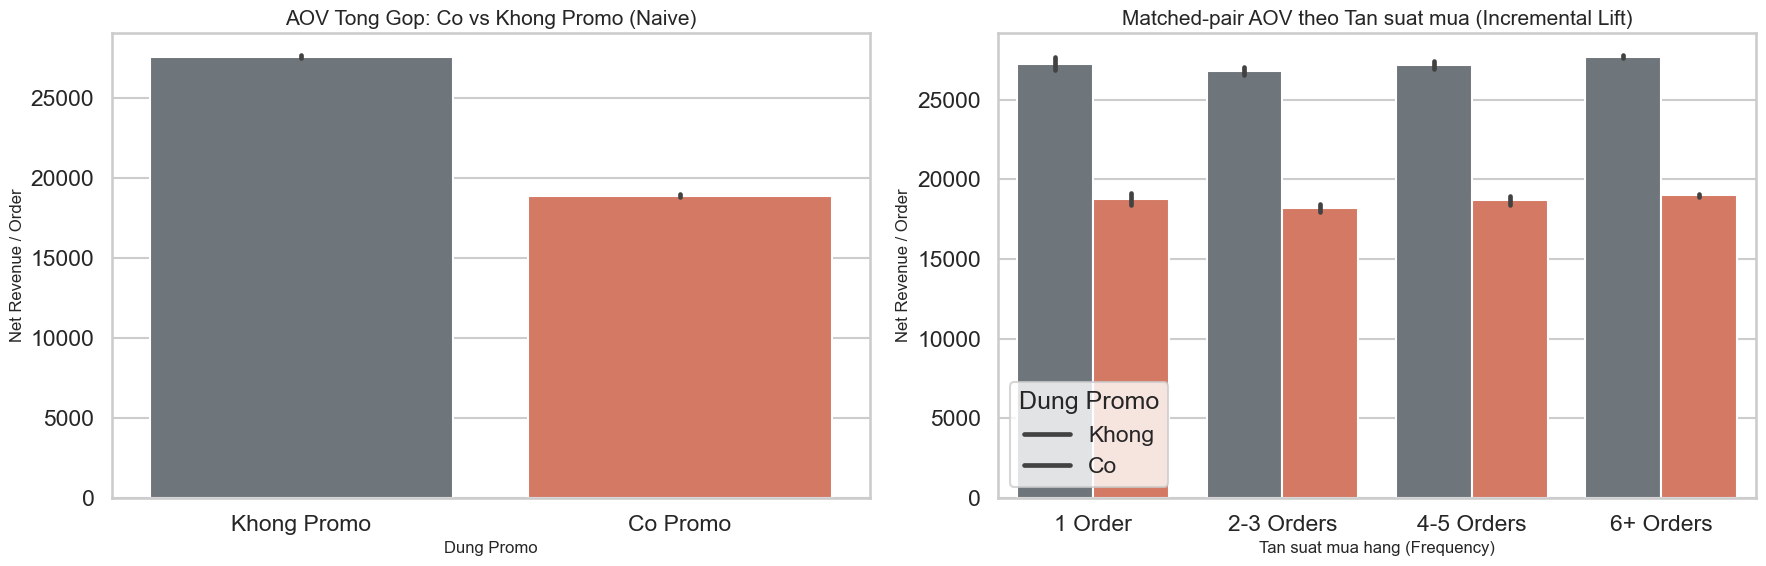

,No_Promo_AOV,Promo_AOV,Incremental_Lift
Frequency_Bucket,,,
1 Order,"$27,250.3","$18,758.1",-31.2%
2-3 Orders,"$26,804.6","$18,219.1",-32.0%
4-5 Orders,"$27,168.9","$18,680.7",-31.2%
6+ Orders,"$27,688.8","$18,984.9",-31.4%


In [39]:
# Phan loai Frequency Buckets cho Matched-pair
def get_freq_bucket(f):
    if pd.isna(f): return "Unknown"
    if f == 1: return "1 Order"
    elif 2 <= f <= 3: return "2-3 Orders"
    elif 4 <= f <= 5: return "4-5 Orders"
    else: return "6+ Orders"

orders_matched = orders_enriched.merge(
    customers_rfm[["customer_id", "Frequency"]], on="customer_id", how="inner"
)
orders_matched["Frequency_Bucket"] = orders_matched["Frequency"].apply(get_freq_bucket)

freq_order = ["1 Order", "2-3 Orders", "4-5 Orders", "6+ Orders"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bieu do AOV Naive (co CI) - fix hue warning
orders_enriched["promo_label"] = orders_enriched["promo_used"].map({True: "Co Promo", False: "Khong Promo"})
sns.barplot(
    data=orders_enriched,
    x="promo_label",
    y="net_revenue",
    hue="promo_label",
    palette={"Khong Promo": "#6c757d", "Co Promo": "#e76f51"},
    legend=False,
    ax=axes[0],
    errorbar=("ci", 95),
    order=["Khong Promo", "Co Promo"]
)
axes[0].set_title("AOV Tong Gop: Co vs Khong Promo (Naive)", fontsize=15)
axes[0].set_xlabel("Dung Promo")
axes[0].set_ylabel("Net Revenue / Order")

# Bieu do Matched Pair (co CI) - hue is already set
sns.barplot(
    data=orders_matched,
    x="Frequency_Bucket",
    y="net_revenue",
    hue="promo_used",
    palette={True: "#e76f51", False: "#6c757d"},
    order=freq_order,
    ax=axes[1],
    errorbar=("ci", 95)
)
axes[1].set_title("Matched-pair AOV theo Tan suat mua (Incremental Lift)", fontsize=15)
axes[1].set_xlabel("Tan suat mua hang (Frequency)")
axes[1].set_ylabel("Net Revenue / Order")
axes[1].legend(title="Dung Promo", labels=["Khong", "Co"])

plt.tight_layout()
plt.show()

# Tinh Incremental Lift %
matched_summary = orders_matched.groupby(
    ["Frequency_Bucket", "promo_used"], as_index=False
)["net_revenue"].mean()
pivot_matched = matched_summary.pivot(
    index="Frequency_Bucket", columns="promo_used", values="net_revenue"
).reindex(freq_order)
pivot_matched.columns = ["No_Promo_AOV", "Promo_AOV"]
pivot_matched["Incremental_Lift"] = (
    (pivot_matched["Promo_AOV"] - pivot_matched["No_Promo_AOV"])
    / pivot_matched["No_Promo_AOV"]
)

display(pivot_matched.style.format({
    "No_Promo_AOV": "${:,.1f}",
    "Promo_AOV": "${:,.1f}",
    "Incremental_Lift": "{:,.1%}"
}).background_gradient(cmap="Greens", subset=["Incremental_Lift"]))


### Hieu suat chuyen doi web traffic

Thay vi chi nhin so don hang, chung ta do ty le `Orders / 1,000 sessions` de danh gia chuyen doi thuc te. 

**Luu y ve bieu do:** De cac nguon traffic de phan biet hon, chung ta dung **FacetGrid** (tach rieng tung nguon) thay vi chong cac duong len nhau.


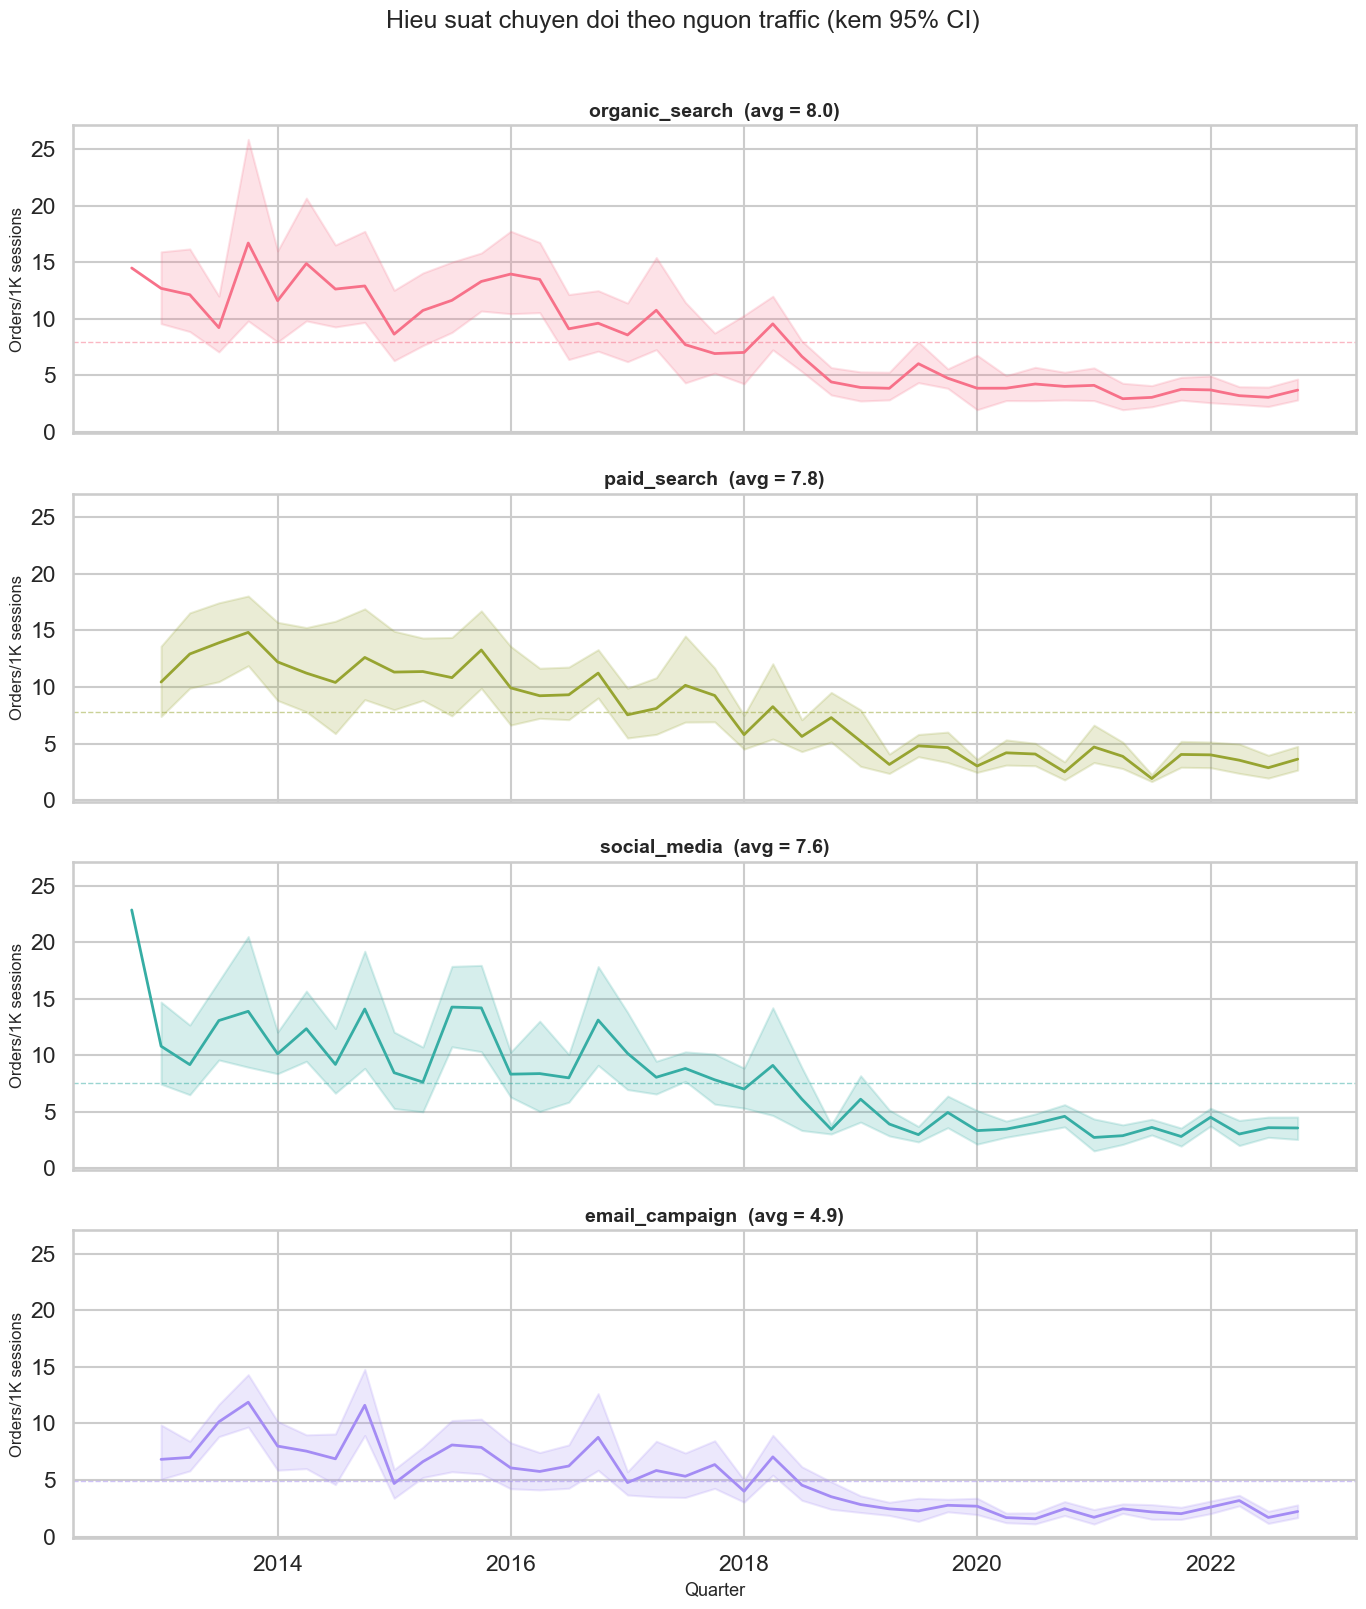

In [40]:
# Su dung data weekly de tinh CI trong moi thang
orders_weekly = (
    orders.assign(week=orders["order_date"].dt.to_period("W").dt.to_timestamp())
    .groupby(["week", "order_source"], as_index=False)
    .size()
    .rename(columns={"size": "orders"})
)
web_weekly = (
    web_traffic.assign(week=web_traffic["date"].dt.to_period("W").dt.to_timestamp())
    .groupby(["week", "traffic_source"], as_index=False)["sessions"]
    .sum()
)
source_eff_weekly = orders_weekly.merge(
    web_weekly, left_on=["week", "order_source"], right_on=["week", "traffic_source"]
)
source_eff_weekly["orders_per_1000_sessions"] = (
    source_eff_weekly["orders"] / source_eff_weekly["sessions"] * 1000
)
source_eff_weekly["quarter"] = source_eff_weekly["week"].dt.to_period("Q").dt.to_timestamp()

top_sources = (
    source_eff_weekly.groupby("order_source")["orders_per_1000_sessions"]
    .mean()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

plot_df = source_eff_weekly[source_eff_weekly["order_source"].isin(top_sources)].copy()

# --- FACETED SUBPLOTS: tach rieng tung nguon traffic ---
n_sources = len(top_sources)
fig, axes = plt.subplots(n_sources, 1, figsize=(14, 4 * n_sources), sharex=True, sharey=True)

colors = sns.color_palette("husl", n_sources)
for idx, source in enumerate(top_sources):
    ax = axes[idx]
    source_data = plot_df[plot_df["order_source"] == source]
    sns.lineplot(
        data=source_data,
        x="quarter",
        y="orders_per_1000_sessions",
        color=colors[idx],
        linewidth=2,
        ax=ax,
        errorbar=("ci", 95),
        err_style="band"
    )
    avg_val = source_data["orders_per_1000_sessions"].mean()
    ax.axhline(y=avg_val, color=colors[idx], linestyle="--", alpha=0.5, linewidth=1)
    ax.set_title(f"{source}  (avg = {avg_val:.1f})", fontsize=14, fontweight="bold")
    ax.set_ylabel("Orders/1K sessions")
    ax.set_xlabel("")

axes[-1].set_xlabel("Quarter", fontsize=13)
fig.suptitle("Hieu suat chuyen doi theo nguon traffic (kem 95% CI)", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()


---
**Nhan dinh tu Chuong 2:** Phan tich matched-pair giup loai bo Selection Bias khi danh gia hieu qua khuyen mai. Bieu do faceted cung giup nhin ro xu huong chuyen doi cua tung kenh traffic ma khong bi chen chuc. Cau hoi cuoi cung: **nguyen nhan Churn that su nam o dau, va chat luong san pham co anh huong khong?**


## Chuong 3. Nguyen nhan Churn & Chat luong san pham

**Muc dich:** Vi Churn Risk duoc tinh tu hanh vi ngung mua (Recency > 90 ngay), chung ta co the kiem tra xem viec khach hang tra hang (Returns) co lam gia tang ty le Churn hay khong, va danh muc nao gay rui ro nay cao nhat.

Day la cau hoi quan trong vi no ket noi giua **chat luong san pham** va **kha nang giu chan khach hang** — 2 yeu to quyet dinh loi nhuan dai han.


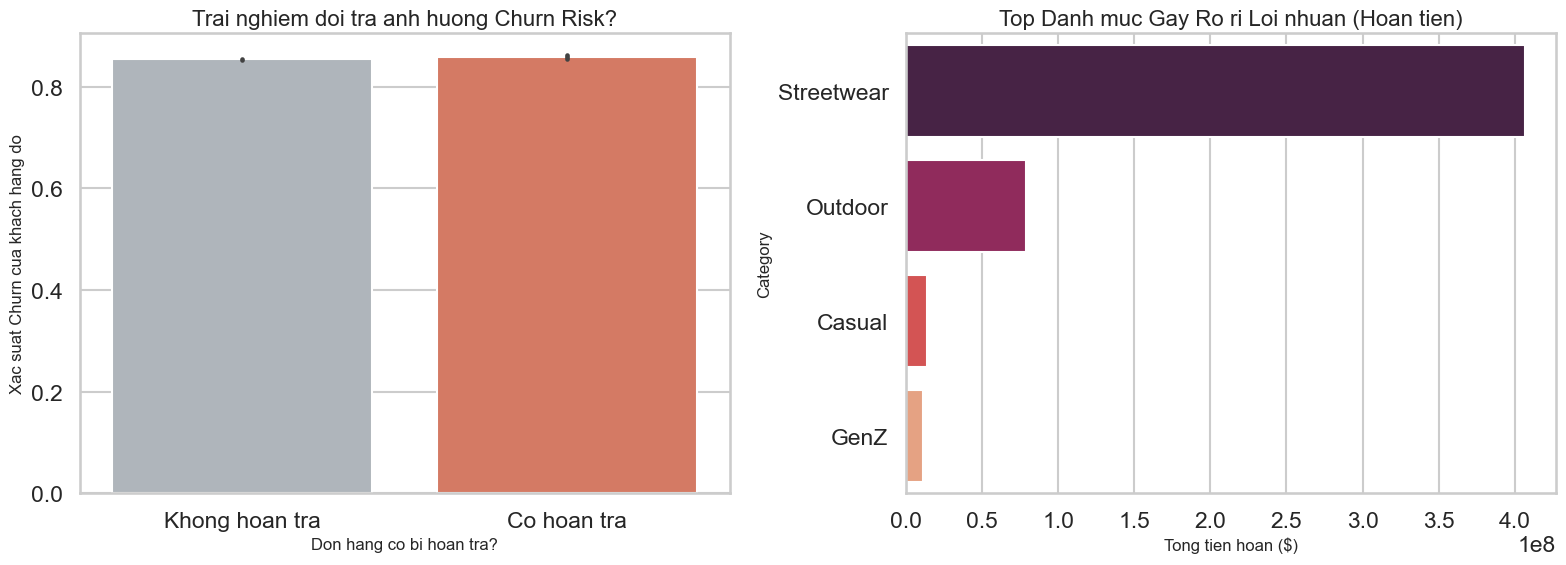

In [41]:
# Loc orders co tra hang
returns_summary = returns.groupby("order_id", as_index=False).agg(
    return_qty=("return_quantity", "sum"),
    refund_amount=("refund_amount", "sum")
)

# Gan thong tin tra hang vao enriched orders
orders_returns = orders_enriched.merge(returns_summary, on="order_id", how="left")
orders_returns["has_return"] = orders_returns["refund_amount"].notna()

# Gan them Churn risk cua khach hang
orders_returns = orders_returns.merge(
    customers_rfm[["customer_id", "Churn_Risk"]], on="customer_id", how="left"
)

# Bieu do tac dong cua Return den Churn Risk
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fix hue warning: map has_return to string label
orders_returns["return_label"] = orders_returns["has_return"].map(
    {True: "Co hoan tra", False: "Khong hoan tra"}
)
sns.barplot(
    data=orders_returns,
    x="return_label",
    y="Churn_Risk",
    hue="return_label",
    palette={"Khong hoan tra": "#adb5bd", "Co hoan tra": "#e76f51"},
    legend=False,
    ax=axes[0],
    errorbar=("ci", 95),
    order=["Khong hoan tra", "Co hoan tra"]
)
axes[0].set_title("Trai nghiem doi tra anh huong Churn Risk?", fontsize=16)
axes[0].set_xlabel("Don hang co bi hoan tra?")
axes[0].set_ylabel("Xac suat Churn cua khach hang do")

# Danh muc hoan tra lon nhat - fix hue warning
category_returns = (
    returns.merge(products[["product_id", "category"]], on="product_id", how="left")
    .groupby("category", as_index=False)
    .agg(
        return_qty=("return_quantity", "sum"),
        refund_amount=("refund_amount", "sum")
    )
).sort_values("refund_amount", ascending=False)

cat_top6 = category_returns.head(6)
sns.barplot(
    data=cat_top6,
    x="refund_amount",
    y="category",
    hue="category",
    palette="rocket",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Top Danh muc Gay Ro ri Loi nhuan (Hoan tien)", fontsize=16)
axes[1].set_xlabel("Tong tien hoan ($)")
axes[1].set_ylabel("Category")

plt.tight_layout()
plt.show()


---
## Ket luan hanh dong

### 1. Giu chan tap Champion/Loyal (RFM-driven Retention)

| Insight | Hanh dong |
|:--------|:---------|
| Tap Champion/Loyal dong gop phan lon doanh thu | Xay dung chuong trinh loyalty rieng, early access san pham moi |
| Nhom "At Risk/Churned" co Recency > 90 ngay | Chay chien dich win-back co nhan hoa (email/SMS) trong vong 60-90 ngay |
| RFM scoring cho phep phan loai dong (dynamic) | Tich hop RFM scoring vao CRM de auto-trigger cac campaign theo segment |

### 2. Khuyen mai can danh gia tren Incremental Lift (khong phai AOV gop)

| Insight | Hanh dong |
|:--------|:---------|
| So sanh AOV naive bi nhieu boi Selection Bias | Luon dung matched-pair hoac A/B test de do luong hieu qua promo |
| Incremental Lift thuc te co the thap hon ky vong | Thu hep doi tuong nhan promo: uu tien nhom "Standard" can kich cau, khong phat code cho nhom da mua nhieu |
| Cac kenh traffic co hieu suat chuyen doi khac nhau | Phan bo ngan sach theo `orders/1,000 sessions` thay vi chi nhin traffic volume |

### 3. Phong ngua Churn bang cach giam rui ro hoan tra

| Insight | Hanh dong |
|:--------|:---------|
| Khach trai qua hoan tra co xac suat Churn cao hon | Uu tien QC cac category top dau ve refund amount |
| Mot so category co return rate va refund cao bat thuong | Kiem tra nguyen nhan goc: mo ta san pham sai, van de kich co, loi van chuyen |
| Giam return rate = giam ro ri loi nhuan *va* giam Churn | Dau tu vao pre-purchase guidance (size chart, video review) cho cac category co van de |

---

> **Luu y ve phuong phap:**
> - **Historical ARPU** la proxy, khong phai true LTV. De tinh LTV chinh xac, can mo hinh du phong nhu BG/NBD + Gamma-Gamma.
> - **Churn Risk** dua tren nguong 90 ngay co dinh. Trong thuc te, nguong nay nen duoc tinh toan tu phan phoi Recency cua tung nganh hang cu the.
> - **Matched-pair analysis** la buoc dau cua causal inference. De co ket qua chac chan hon, can thiet ke A/B test hoac su dung propensity score matching.

Notebook nay phu hop de dung nhu mot ban ke chuyen du lieu o vong trinh bay: moi bieu do tra loi mot cau hoi quan tri, moi chuong dan den chuong tiep theo theo logic tu nhien.
